# 2D Schrodinger equation eigensolver

This notebook is the working demo for `Eigensolver_2Dimensions.py`: a finite-difference
eigensolver for the 2D time-independent Schrodinger equation, extending my
[1D eigensolver](https://github.com/Chumita003/1D_SchrodingerEigensolver) to two
dimensions. See the README for the full write-up, including the numerical checks
(boundary-stencil convergence, degenerate-eigenvalue behavior, and the 2D delta well's
divergence) that this notebook only summarizes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

from Eigensolver_2Dimensions import (
    Schrodinger_solver_2D,
    V_HarmonicOscillator_2D,
    V_DoubleWell_2D,
    V_InfiniteSquareWell_2D,
    V_DeltaDiscrete_2D,
    plot_eigenfunction_grid,
    plot_eigenfunction_surface,
    plot_energy_levels_2d,
)

## Anisotropic harmonic oscillator

$V(x,y) = \tfrac12 m(\omega_x^2 x^2 + \omega_y^2 y^2)$, separable, with exact spectrum
$E_{n_x,n_y} = \hbar\omega_x(n_x+\tfrac12) + \hbar\omega_y(n_y+\tfrac12)$. I used
$\omega_x \neq \omega_y$ on purpose here, see the "degenerate eigenvalues" section
of the README for why.

In [2]:
x, y, eigvals, eigvecs = Schrodinger_solver_2D(
    V_pot=partial(V_HarmonicOscillator_2D, omega_x=1.0, omega_y=1.7, m=1.0),
    x_min=-8.0, x_max=8.0, y_min=-8.0, y_max=8.0,
    Nx=80, Ny=80, num_eigvals=6,
)
ho_labels = ["(0,0)", "(1,0)", "(0,1)", "(2,0)", "(1,1)", "(3,0)"]
for n, En in enumerate(eigvals):
    print(f"n={n}  (nx,ny)={ho_labels[n]}:  E = {En:.6f}")

n=0  (nx,ny)=(0,0):  E = 1.349898
n=1  (nx,ny)=(1,0):  E = 2.349795
n=2  (nx,ny)=(0,1):  E = 3.049396
n=3  (nx,ny)=(2,0):  E = 3.349486
n=4  (nx,ny)=(1,1):  E = 4.049292
n=5  (nx,ny)=(3,0):  E = 4.348839


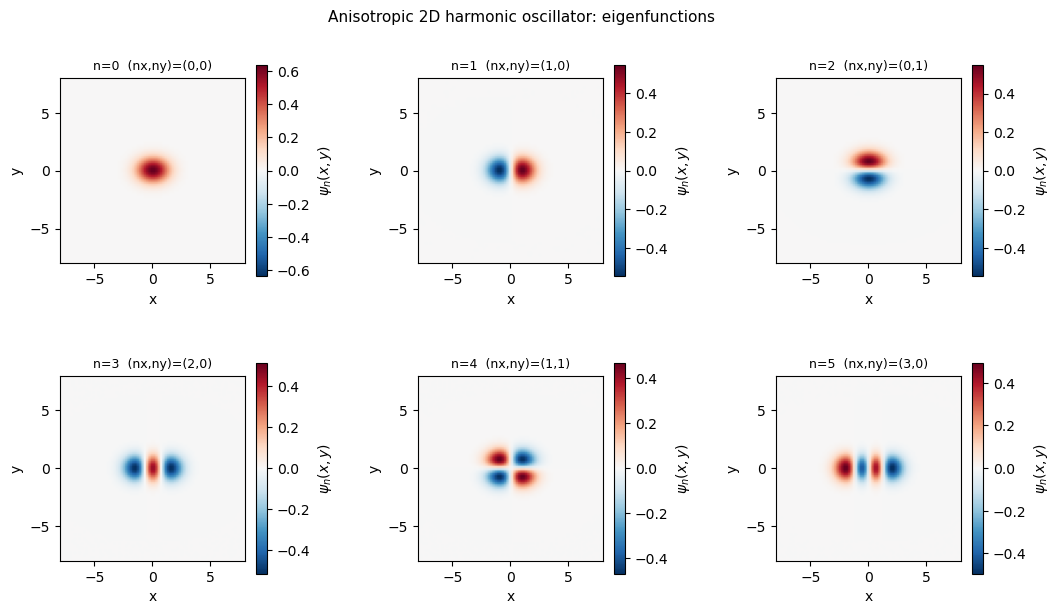

In [3]:
plot_eigenfunction_grid(
    x, y, eigvecs, n_states=6, ncols=3,
    titles=[f"n={n}  (nx,ny)={ho_labels[n]}" for n in range(6)],
    suptitle="Anisotropic 2D harmonic oscillator: eigenfunctions",
)
plt.show()

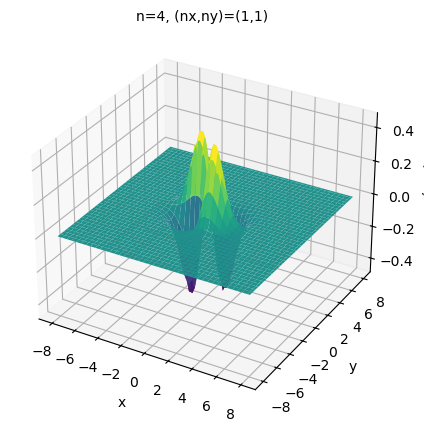

In [4]:
plot_eigenfunction_surface(x, y, eigvecs, n=4, title="n=4, (nx,ny)=(1,1)")
plt.show()

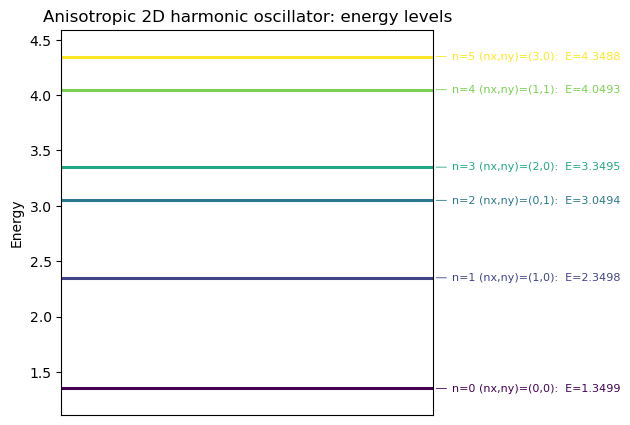

In [5]:
plot_energy_levels_2d(
    eigvals, n_states=6, labels=[f"(nx,ny)={l}" for l in ho_labels],
    title="Anisotropic 2D harmonic oscillator: energy levels",
)
plt.show()

## Double well in x, harmonic in y

$V(x,y) = V_x(x^2-a^2)^2 + V_y y^2$. No closed form, but separable, so
$E = E_x + E_y$: the x-tunneling doublet should reappear, shifted by the same amount,
once for every quantum of y-motion. That is exactly what comes out below.

In [6]:
x, y, eigvals, eigvecs = Schrodinger_solver_2D(
    V_pot=partial(V_DoubleWell_2D, a=1.5, Vx=1.0, Vy=3.0),
    x_min=-4.0, x_max=4.0, y_min=-4.0, y_max=4.0,
    Nx=80, Ny=80, num_eigvals=6,
)
dw_labels = ["(0,0)", "(1,0)", "(0,1)", "(1,1)", "(2,0)", "(3,0)"]
for n, En in enumerate(eigvals):
    print(f"n={n}  (nx,ny)={dw_labels[n]}:  E = {En:.6f}")

print(f"\nTunneling splitting, ny=0 doublet (n=0,1): {eigvals[1]-eigvals[0]:.5e}")
print(f"Tunneling splitting, ny=1 doublet (n=2,3): {eigvals[3]-eigvals[2]:.5e}")
print(f"Gap between doublets (n=2 - n=0): {eigvals[2]-eigvals[0]:.4f}  (expected ~sqrt(2*Vy/m) = {np.sqrt(6):.4f})")

n=0  (nx,ny)=(0,0):  E = 3.195253
n=1  (nx,ny)=(1,0):  E = 3.237070
n=2  (nx,ny)=(0,1):  E = 5.644647
n=3  (nx,ny)=(1,1):  E = 5.686464
n=4  (nx,ny)=(2,0):  E = 6.132618
n=5  (nx,ny)=(3,0):  E = 6.998001

Tunneling splitting, ny=0 doublet (n=0,1): 4.18171e-02
Tunneling splitting, ny=1 doublet (n=2,3): 4.18171e-02
Gap between doublets (n=2 - n=0): 2.4494  (expected ~sqrt(2*Vy/m) = 2.4495)


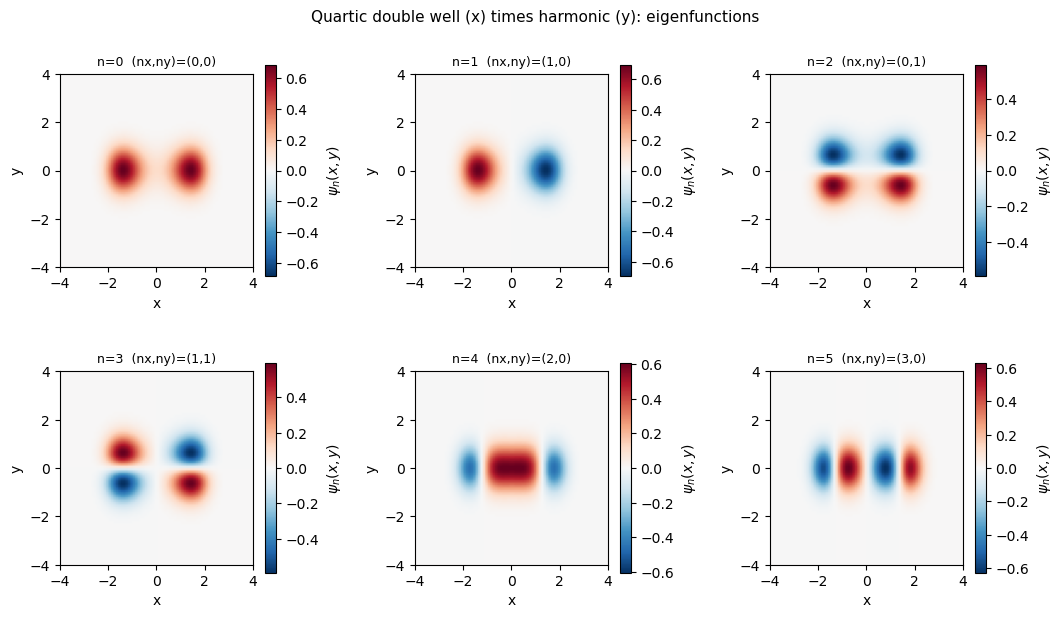

In [7]:
plot_eigenfunction_grid(
    x, y, eigvecs, n_states=6, ncols=3,
    titles=[f"n={n}  (nx,ny)={dw_labels[n]}" for n in range(6)],
    suptitle="Quartic double well (x) times harmonic (y): eigenfunctions",
)
plt.show()

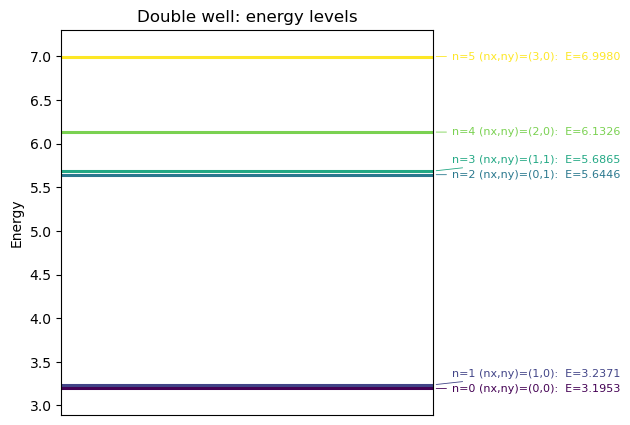

In [8]:
plot_energy_levels_2d(eigvals, n_states=6, labels=[f"(nx,ny)={l}" for l in dw_labels],
                       title="Double well: energy levels")
plt.show()

## Validation against analytic solutions

`validate_2d.py` runs this as a standalone script, reproduced here: a rectangular
infinite well ($L_x=12$, $L_y=8$) and the anisotropic oscillator above, both compared
against their closed-form spectra. Both potentials are deliberately non-degenerate
(rectangular, not square; anisotropic, not isotropic), for the reason explained in the
README's "degenerate eigenvalues and Krylov methods" section.

In [9]:
from validate_2d import (
    validate_infinite_square_well_2d,
    validate_harmonic_oscillator_2d,
    print_table,
)

ns, num, an, err = validate_infinite_square_well_2d()
print_table("Infinite square well, rectangular (Lx=12, Ly=8, N=90)", ns, num, an, err)

ns, num, an, err = validate_harmonic_oscillator_2d()
print_table("Harmonic oscillator, anisotropic (wx=1, wy=1.7, N=90)", ns, num, an, err)


Infinite square well, rectangular (Lx=12, Ly=8, N=90)
  n        numeric       analytic   rel. error
  0     0.11137574     0.11137574    1.725e-08
  1     0.21418408     0.21418412    1.828e-07
  2     0.34269451     0.34269460    2.500e-07
  3     0.38553099     0.38553142    1.120e-06
  4     0.44550285     0.44550298    2.759e-07
  5     0.61684976     0.61685028    8.359e-07

Harmonic oscillator, anisotropic (wx=1, wy=1.7, N=90)
  n        numeric       analytic   rel. error
  0     1.34993665     1.35000000    4.692e-05
  1     2.34987222     2.35000000    5.437e-05
  2     3.04962285     3.05000000    1.237e-04
  3     3.34967973     3.35000000    9.560e-05
  4     4.04955842     4.05000000    1.090e-04
  5     4.34927537     4.35000000    1.666e-04


The square well sits at a flat ~3.5e-3 relative error across every level; the
oscillator is three orders of magnitude tighter. Same qualitative story as the 1D
project: this is the boundary-stencil limitation, not something that grows with $n$.

## Convergence check: the boundary closure in 2D

Same mechanism as the 1D code (see its README): the rows adjacent to each Dirichlet
boundary need a point outside the domain. Closing the stencil with the odd extension
$\psi_{-1}=-\psi_1$ adds $+1/(12\,dx^2)$ to the first and last diagonal entries, which is
diagonal-only and so keeps $H$ Hermitian even after the Kronecker sum. That restores the
stencil's design order globally, $O(1/N^4)$ instead of the $O(1/N)$ this used to show. I
did not assume it carries over unchanged from 1D to 2D, I measured it.

N=   30   rel. error=1.529e-06
N=   45   rel. error=2.886e-07   local slope p=4.11
N=   65   rel. error=6.450e-08   local slope p=4.08
N=   90   rel. error=1.725e-08   local slope p=4.05
N=  120   rel. error=5.397e-09   local slope p=4.04


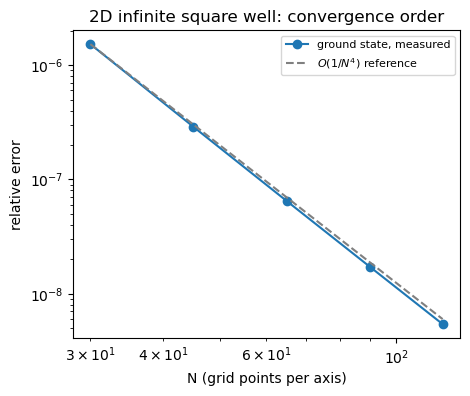

In [10]:
from validate_2d import convergence_study_isw_2d

Ns, errs = convergence_study_isw_2d()
slopes = -np.log(errs[1:] / errs[:-1]) / np.log(Ns[1:] / Ns[:-1])
for i, (N, e) in enumerate(zip(Ns, errs)):
    tag = f"   local slope p={slopes[i-1]:.2f}" if i > 0 else ""
    print(f"N={N:>5}   rel. error={e:.3e}{tag}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.loglog(Ns, errs, "o-", label="ground state, measured")
ax.loglog(Ns, errs[0] * (Ns[0] / Ns) ** 4, "--", color="gray", label=r"$O(1/N^4)$ reference")
ax.set_xlabel("N (grid points per axis)")
ax.set_ylabel("relative error")
ax.set_title("2D infinite square well: convergence order")
ax.legend(fontsize=8)
plt.show()

## The 2D delta well: no continuum limit

I assumed `V_DeltaDiscrete_2D` would converge slowly, like its 1D counterpart does. It
doesn't converge at all: the continuum 2D Dirac delta potential has no bound-state energy
scale without an explicit regularization, and the grid spacing here is acting as that
regularization. Refining the grid doesn't approach a hidden true answer, it just changes
the effective cutoff. See the README for the full explanation.

N=   30   E0=-0.788236
N=   50   E0=-2.250362
N=   70   E0=-4.462296
N=   90   E0=-7.424039


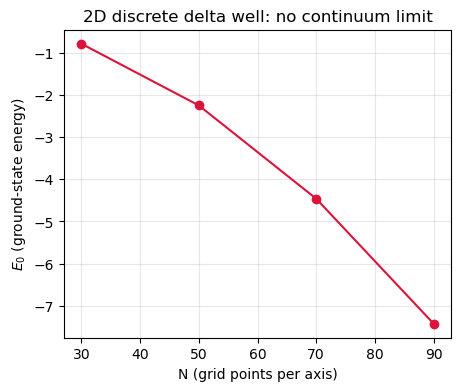

In [11]:
from validate_2d import delta_well_2d_divergence_study

Ns_d, E0s = delta_well_2d_divergence_study()
for N, E0 in zip(Ns_d, E0s):
    print(f"N={N:>5}   E0={E0:.6f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(Ns_d, E0s, "o-", color="crimson")
ax.set_xlabel("N (grid points per axis)")
ax.set_ylabel(r"$E_0$ (ground-state energy)")
ax.set_title("2D discrete delta well: no continuum limit")
ax.grid(alpha=0.3)
plt.show()